🧠 Memulai pelatihan Intensif (100.000 langkah)...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 100       |
|    ep_rew_mean     | -1.19e+04 |
| time/              |           |
|    fps             | 4803      |
|    iterations      | 1         |
|    time_elapsed    | 0         |
|    total_timesteps | 2048      |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 100          |
|    ep_rew_mean          | -1.3e+04     |
| time/                   |              |
|    fps                  | 3312         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0040024444 |
|    clip_fraction        | 0    

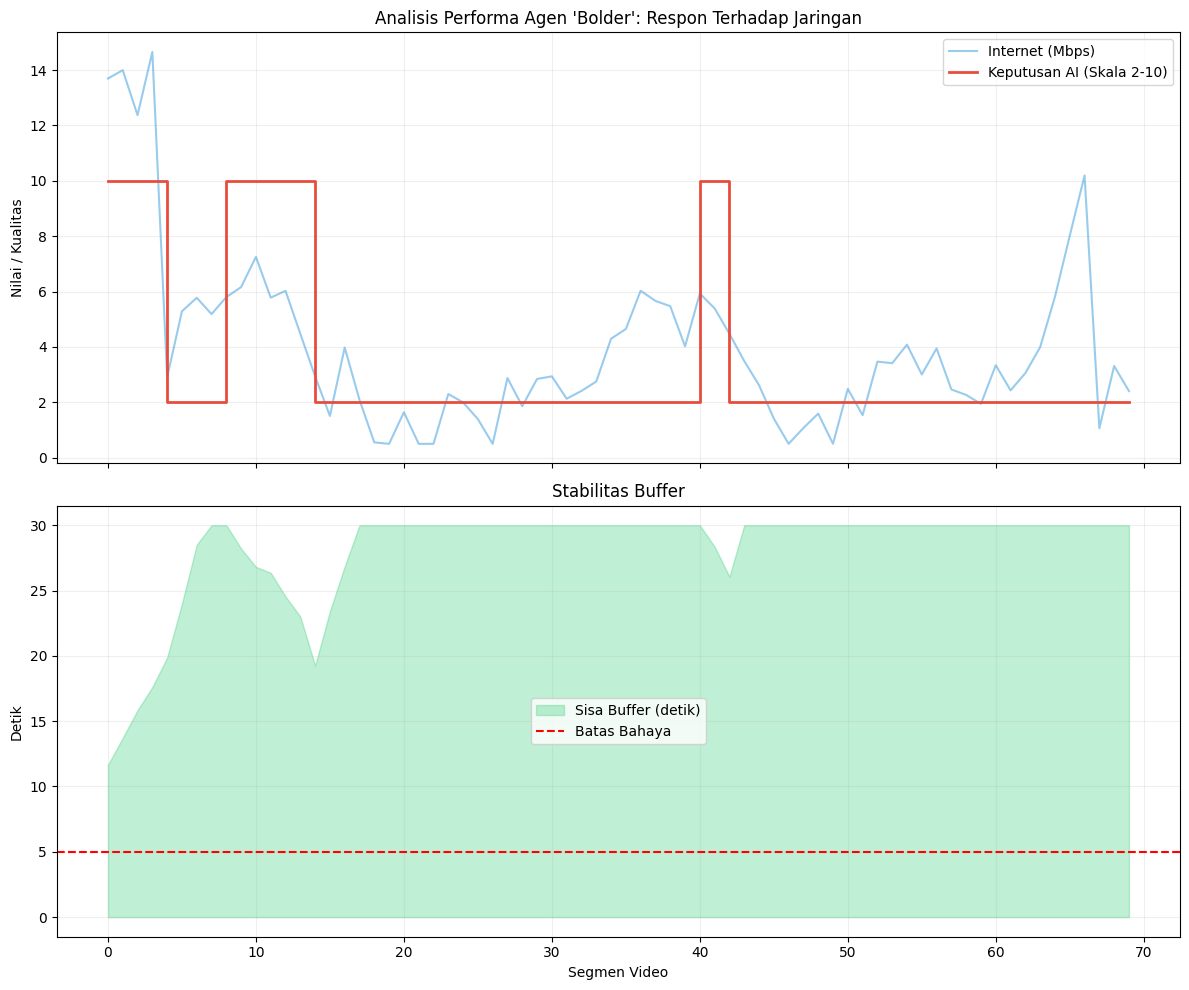


--- Analisis Keputusan (10 Data Pertama) ---
   Langkah  Throughput     Buffer Kualitas
0        0   13.697165  11.654215        2
1        1   13.997539  13.724630        2
2        2   12.374279  15.845379        2
3        3   14.657003  17.609819        2
4        4    2.906956  19.866669        2
5        5    5.287196  24.003265        0
6        6    5.775179  28.504730        0
7        7    5.186671  30.000000        0
8        8    5.800122  30.000000        0
9        9    6.162297  28.210480        2


In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import pandas as pd

class BolderShakaEnv(gym.Env):
    """
    Simulator Lingkungan dengan Reward Agresif untuk memaksa Agen 
    menggunakan kualitas tinggi pada jaringan NDN yang mumpuni.
    """
    def __init__(self):
        super(BolderShakaEnv, self).__init__()
        
        # Action: 0=Low (0.5), 1=Mid (2.5), 2=High (8.0 Mbps)
        self.action_space = spaces.Discrete(3)
        self.bitrates = [0.5, 2.5, 8.0]

        # Obs: [Buffer(0-30), Throughput(0-20), LastQual(0-2), RTT(0-1000), Dropped(0-100)]
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, 0, 0]),
            high=np.array([30, 20, 2, 1000, 100]),
            dtype=np.float32
        )

        self.state = None
        self.current_step = 0
        self.max_steps = 100

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Mulai dengan kondisi internet yang cukup baik
        self.state = np.array([10.0, 12.0, 1.0, 40.0, 0.0], dtype=np.float32)
        self.current_step = 0
        return self.state, {}

    def step(self, action):
        buffer, throughput, last_qual, rtt, dropped = self.state
        chosen_bitrate = self.bitrates[action]
        
        # Simulasi Fisika Video
        seg_dur = 5.0
        # Waktu download dipengaruhi oleh NDN throughput dan latensi
        download_time = (chosen_bitrate * seg_dur / (throughput + 0.1)) + (rtt / 1000.0)
        
        # Hitung Stalling (Macet)
        stalling = max(0, download_time - buffer)
        new_buffer = max(0, buffer - download_time) + seg_dur
        new_buffer = min(new_buffer, 30.0)

        # --- LOGIKA REWARD BARU (LEBIH BERANI) ---
        # 1. Hadiah Bitrate Eksponensial (Semakin tinggi semakin menguntungkan)
        reward = (chosen_bitrate ** 1.5) 

        # 2. Penalti Macet (Tetap berat tapi proporsional)
        if stalling > 0:
            reward -= (stalling * 40.0)
        
        # 3. Penalti "Pemborosan Jaringan" (CRITICAL)
        # Menghukum agen jika pilih Low (action 0) padahal internet kencang (>10Mbps) dan buffer aman (>15s)
        if action == 0 and throughput > 10.0 and buffer > 15.0:
            reward -= 10.0 

        # 4. Penalti Ketidakstabilan (Switching)
        reward -= abs(action - last_qual) * 3.0

        # Fluktuasi Jaringan (Dibuat lebih dinamis)
        # Terkadang internet drop tiba-tiba untuk menguji ketangguhan
        if np.random.rand() < 0.1: # 10% peluang gangguan mendadak
            new_throughput = np.random.uniform(0.5, 3.0)
        else:
            new_throughput = np.clip(throughput + np.random.uniform(-2, 2.5), 0.5, 20.0)
            
        new_rtt = np.clip(rtt + np.random.uniform(-20, 20), 10, 600)

        self.state = np.array([new_buffer, new_throughput, float(action), new_rtt, 0.0], dtype=np.float32)
        self.current_step += 1
        done = self.current_step >= self.max_steps
        
        return self.state, reward, done, False, {}

def run_training():
    print("🧠 Memulai pelatihan Intensif (100.000 langkah)...")
    env = BolderShakaEnv()
    
    # Menggunakan PPO dengan learning rate yang lebih stabil
    model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.0002)
    model.learn(total_timesteps=100000)
    
    print("📊 Menjalankan Evaluasi Skenario...")
    obs, _ = env.reset()
    results = []
    
    # Skenario: 25 step internet kencang, 25 step internet drop
    for i in range(70):
        if i == 30: # Simulasikan gangguan kabel/jaringan pada step 30
            obs[1] = 1.0 
            
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = env.step(action)
        results.append({
            'Langkah': i,
            'Throughput': obs[1],
            'Buffer': obs[0],
            'Kualitas': action,
            'Reward': reward
        })

    df = pd.DataFrame(results)

    # Visualisasi
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # Plot 1: Keputusan AI vs Jaringan
    ax1.plot(df['Langkah'], df['Throughput'], label='Internet (Mbps)', color='#3498db', alpha=0.5)
    ax1.step(df['Langkah'], df['Kualitas'] * 4 + 2, label='Keputusan AI (Skala 2-10)', color='#e74c3c', linewidth=2)
    ax1.set_title("Analisis Performa Agen 'Bolder': Respon Terhadap Jaringan")
    ax1.set_ylabel("Nilai / Kualitas")
    ax1.legend()
    ax1.grid(alpha=0.2)

    # Plot 2: Kondisi Buffer
    ax2.fill_between(df['Langkah'], df['Buffer'], color='#2ecc71', alpha=0.3, label='Sisa Buffer (detik)')
    ax2.axhline(y=5, color='red', linestyle='--', label='Batas Bahaya')
    ax2.set_title("Stabilitas Buffer")
    ax2.set_ylabel("Detik")
    ax2.set_xlabel("Segmen Video")
    ax2.legend()
    ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()
    
    print("\n--- Analisis Keputusan (10 Data Pertama) ---")
    print(df[['Langkah', 'Throughput', 'Buffer', 'Kualitas']].head(10))

if __name__ == "__main__":
    run_training()